# Gymnasium: BipedalWalker-v3

Our objective is to train an agent to navigate the BipedalWalker environment using Reinforcement Learning. Before implementing complex algorithms or aiming for advanced maneuvers (like doing a flip), we need to understand the environment's dynamics.

## Environment Overview
`BipedalWalker-v3` is a 2D physics simulation environment from the Gymnasium Box2D environments. The goal is to make a bipedal robot walk to the right end of the terrain. In the `hardcore=True` version, the terrain is not flat; it includes obstacles such as ladders, stumps, and pitfalls.

### Action Space
The action space is a continuous `Box(-1.0, 1.0, (4,), float32)`. The agent controls the robot by applying torques to its four main joints. The four values in the action array represent:
1. Hip 1 (Torque / Speed)
2. Knee 1 (Torque / Speed)
3. Hip 2 (Torque / Speed)
4. Knee 2 (Torque / Speed)

All action values must be within the `[-1.0, 1.0]` range.

### Reward System
The agent receives rewards based on its forward progress and energy efficiency. According to the official documentation, the reward is calculated as follows:
* **Forward Movement:** The agent is rewarded for moving forward (to the right). Reaching the end of the terrain yields a total of over 300 points.
* **Falling Penalty:** If the robot's main body (hull) touches the ground, it falls. This results in a heavy penalty of **-100** points, and the episode terminates immediately.
* **Motor Torque Penalty:** To encourage efficient, natural walking rather than chaotic flailing, applying motor torque costs a small negative reward.
### Set up the Environment

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import gymnasium as gym
env = gym.make("BipedalWalker-v3", hardcore=False, render_mode="human") # Human we can see the environment

## Baseline: Random Actions

To establish a baseline and visualize how an untrained agent interacts with the physics engine, we will run a single episode using a random policy. The agent will sample actions uniformly from the action space until the episode ends.

An episode ends if:
- `terminated` is True (the agent falls or reaches the goal).
- `truncated` is True (the agent runs out of time/steps).
- Past 20 seconds of simulation time.

In [21]:
import time

env = gym.make("BipedalWalker-v3", hardcore=False, render_mode="human") 
limit_time = 10  # seconds
start_time = time.time()
obs, info = env.reset()

terminated = False
truncated = False
total_reward = 0.0
step_count = 0

# Loop until the agent finishes or fails
while not (terminated or truncated) and (time.time() - start_time < limit_time):
    # Sample a random continuous action within [-1, 1] for the 4 joints
    action = env.action_space.sample() 
    
    # Step the environment forward
    obs, reward, terminated, truncated, info = env.step(action)
    
    total_reward += reward
    step_count += 1

# Close the rendering window
env.close()

print(f"Episode finished after {step_count} steps.")
print(f"Total Reward with random policy: {total_reward:.2f}")

Episode finished after 52 steps.
Total Reward with random policy: -105.10


### Changing the Environment
Instead of training the agent only to walk, we can reshape the task so it learns to perform a flip.
The main idea is to change the reward and encourage trunk rotation, airtime, and landing control.


Changes in the robot:
- Track the robot body's orientation.
- Reward angular velocity and rotation progress.
- Give a large bonus when the agent completes a full rotation.
- Reduce the fall penalty so the agent is willing to take risks.
- Penalize forward movement less, so the policy focuses on flipping rather than walking.

In [1]:
import gymnasium as gym
import numpy as np
import custom_bipedal
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

class CurriculumFlipperWrapper(gym.Wrapper):
    def __init__(self, env, stage=1, max_steps=1500):
        super().__init__(env)
        self.max_steps = max_steps
        self.stage = stage 
        
        # Initialize tracking variables (will be reset in reset())
        self.cumulative_angle = 0.0
        self.prev_angle = 0.0
        self.flip_completed = False
        self.step_counter = 0
        
        # Expand observation space to include continuous absolute angle progress
        low = np.append(self.env.observation_space.low, -np.inf)
        high = np.append(self.env.observation_space.high, np.inf)
        self.observation_space = gym.spaces.Box(low, high, dtype=np.float32)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.step_counter += 1

        current_angle = obs[0]
        delta_angle = current_angle - self.prev_angle

        # Handle wrap-around
        if delta_angle > np.pi:
            delta_angle -= 2 * np.pi
        elif delta_angle < -np.pi:
            delta_angle += 2 * np.pi

        prev_cumulative = self.cumulative_angle
        self.cumulative_angle += delta_angle
        self.prev_angle = current_angle

        # Use absolute values so Backflips are equally rewarded!
        abs_angle = abs(self.cumulative_angle)
        abs_prev = abs(prev_cumulative)
        
        custom_reward = 0.0

        # 1. Base Rotation Rewards
        custom_reward += abs(obs[1]) * 5.0  # Reward raw rotational speed in either direction
        
        # Because we use abs(), wiggling back and forth yields negative progress!
        rotation_progress = abs_angle - abs_prev
        custom_reward += rotation_progress * 15.0 

        # Airtime bonus
        is_airborne = (obs[8] == 0.0 and obs[13] == 0.0)

        # Tuck bonus: Encourage retracting knees while spinning in mid-air (between 1.0 and 4.5 rad of rotation)
        if is_airborne and (1.0 <= abs_angle < 4.5):
            # obs[6] and obs[11] are knee_angle + 1.0. 
            # Bending knees brings them to -0.6, straightening them brings them to 0.9.
            tuck_bonus = - (obs[6] + obs[11])  # Range: [-1.8, 1.2]
            custom_reward += tuck_bonus * 8.0  # Moderate reward to strongly incentivize tucking

        # Intermediate milestones
        milestones = [np.pi / 2, np.pi, 3 * np.pi / 2]
        for milestone in milestones:
            attr = f"_milestone_{milestone:.2f}_done"
            if not getattr(self, attr, False) and abs_angle >= milestone:
                setattr(self, attr, True)
                custom_reward += 50.0

        # 2. Flip Completion (Threshold lowered to 5.2 rad to bridge sparse reward gap)
        if abs_angle >= 5.2 and not self.flip_completed:
            self.flip_completed = True
            custom_reward += 300.0 

        # 3. Stage-Specific Logic
        is_falling = (reward == -100)
        
        if self.stage == 1:
            if is_airborne:
                custom_reward += 5.0  # High baseline airtime reward
                try:
                    hull_y = self.env.unwrapped.hull.position[1]
                    jump_height = max(0.0, hull_y - 5.5)
                    custom_reward += jump_height * 20.0  # Encourage a high jump to get height/airtime
                except Exception:
                    pass
            if is_falling:
                custom_reward += 100.0 
                
        elif self.stage == 2:
            if is_airborne:
                custom_reward += 1.0
                
            # PROGRESSIVE LANDING PREPARATION (Start at 4.0 rad to give joints plenty of swing time)
            if abs_angle >= 4.0:
                # Wrap the hull angle to [-pi, pi] to get physical upright orientation
                wrapped_angle = obs[0] % (2 * np.pi)
                if wrapped_angle > np.pi:
                    wrapped_angle -= 2 * np.pi
                
                # 1. Progressive Upright alignment using the wrapped angle
                upright_bonus = np.cos(wrapped_angle) 
                if upright_bonus > 0.75: 
                    custom_reward += upright_bonus * 12.0
                else:
                    custom_reward -= abs(wrapped_angle) * 5.0 
                
                # 2. Active leg preparation (Encourage swinging feet below the hull)
                try:
                    hull_y = self.env.unwrapped.hull.position[1]
                    leg1_y = self.env.unwrapped.legs[1].position[1]
                    leg2_y = self.env.unwrapped.legs[3].position[1]
                    if leg1_y < hull_y and leg2_y < hull_y:
                        custom_reward += 10.0  # Strong reward for feet pointing down
                except Exception:
                    pass

                # Avoid excessive rotation as landing approaches
                custom_reward -= abs(obs[1]) * 3.0

            # Direct landing rewards (only active once flip is completed)
            if self.flip_completed:
                # Two feet landing
                if obs[8] == 1.0 and obs[13] == 1.0:
                    custom_reward += 40.0 # max reward for two feet landing
                elif obs[8] == 1.0 or obs[13] == 1.0:
                    custom_reward += 10.0  # small reward for one feet
                    
                # Avoid hard landing
                y_vel = obs[3] 
                if y_vel < -1.5: 
                    custom_reward += (y_vel + 1.5) * 4.0 
                
                # Bonus for survival
                if not terminated:
                    custom_reward += 8.0
            
            # Fall penalty logic (Wipe out flip bonus if it crashes after completing the flip!)
            if is_falling:
                if self.flip_completed:
                    custom_reward -= 350.0  # Severe penalty to completely discourage crash-landing
                else:
                    custom_reward -= 50.0


        if self.step_counter >= self.max_steps:
            truncated = True

        info['flip_completed'] = self.flip_completed
        info['cumulative_angle'] = self.cumulative_angle

        total_reward = reward + custom_reward

        # Feed the absolute angle percentage to the observation network
        obs = np.append(obs, abs_angle / (2 * np.pi)).astype(np.float32)
        return obs, total_reward, terminated, truncated, info

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        
        # Lower gravity in the custom environment unwrapped world
        #self.env.unwrapped.world.gravity = (0.0, -5.0)

        self.cumulative_angle = 0.0
        self.prev_angle = obs[0]
        self.flip_completed = False
        self.step_counter = 0
        for milestone in [np.pi / 2, np.pi, 3 * np.pi / 2]:
            setattr(self, f"_milestone_{milestone:.2f}_done", False)
            
        obs = np.append(obs, 0.0).astype(np.float32)
        return obs, info

def make_env(stage):
    def _init():
        # Instantiate from custom_bipedal
        env = custom_bipedal.BipedalWalker()
        env = CurriculumFlipperWrapper(env, stage=stage)
        return env
    return _init


## Integrating Stable Baselines 3

Using Stable Baselines 3, we can implement a Proximal Policy Optimization (PPO) agent to learn how to flip in the BipedalWalker environment.

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
import torch

# --- STAGE 1: ROTATION 
def make_env_stage1():
    def _init():
        e = custom_bipedal.BipedalWalker(hardcore=False)
        return CurriculumFlipperWrapper(e, stage=1)
    return _init

vec_env_s1 = SubprocVecEnv([make_env_stage1() for _ in range(16)])

model = PPO("MlpPolicy", vec_env_s1, verbose=1, device="cpu", 
            n_steps=1024, batch_size=256, learning_rate=3e-4,
            tensorboard_log="./ppo_bipedal_curriculum/")

print("Starting Stage 1: Rotation Mastery...")
model.learn(total_timesteps=800_000) 
model.save("ppo_bipedal_stage1")
vec_env_s1.close()

# --- STAGE 2: LANDING
def make_env_stage2():
    def _init():
        e = custom_bipedal.BipedalWalker(hardcore=False)
        return CurriculumFlipperWrapper(e, stage=2)
    return _init

num_envs = 16
vec_env_s2 = SubprocVecEnv([make_env_stage2() for _ in range(num_envs)])

print("\nStarting Stage 2: Stabilization and Landing (Speed-Optimized)...")
model = PPO.load(
    "ppo_bipedal_stage1", 
    env=vec_env_s2, 
    device="cpu",
    custom_objects={
        "learning_rate": 5e-5,
        "lr_schedule": lambda _: 5e-5,  # Force fine-tuning LR schedule
        "n_steps": 1024                 # More frequent updates (16 * 1024 = 16,384 steps per update)
    }
)

# Reset exploration standard deviation to promote landing adjustments
with torch.no_grad():
    model.policy.log_std.fill_(-1.0)  # exp(-1.0) ≈ 0.37 action standard deviation for stronger exploration

model.learn(total_timesteps=800_000) 
model.save("ppo_bipedal_final")
vec_env_s2.close()


Using cpu device
Starting Stage 1: Rotation Mastery...
Logging to ./ppo_bipedal_curriculum/PPO_20
------------------------------
| time/              |       |
|    fps             | 3224  |
|    iterations      | 1     |
|    time_elapsed    | 5     |
|    total_timesteps | 16384 |
------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2626         |
|    iterations           | 2            |
|    time_elapsed         | 12           |
|    total_timesteps      | 32768        |
| train/                  |              |
|    approx_kl            | 0.0066575613 |
|    clip_fraction        | 0.0679       |
|    clip_range           | 0.2          |
|    entropy_loss         | -5.66        |
|    explained_variance   | 0.0031       |
|    learning_rate        | 0.0003       |
|    loss                 | 1.21e+03     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00738    

### Testing Model


🤖 BIPEDAL WALKER FLIPPER EVALUATION RUN 🤖
• Hardware Device: CUDA
• Evaluation Stage: Stage 2 (Stabilization and Landing)
• Loading weights from: ppo_bipedal_final.zip...


c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


• Model loaded successfully! Starting evaluation...

🤸 TEST EPISODE 1 / 5
[Live Event Log]
  ↳ 🔄 Milestone 90° passed at step 57
  ↳ 🔄 Milestone 180° passed at step 66
  ↳ 🔄 Milestone 270° passed at step 78
  ↳ 🌟 [360° FULL FLIP COMPLETED!] at step 91

[Episode Summary]
  • Outcome:           🟡 FLIPPED but CRASHED / OFF-BALANCE
  • Total Reward:      1529.37
  • Total Steps:       131 steps
  • Max Rotation:      539.8° / 360.0° (1.5 flips)
  • Airtime:           82.4% of episode
  • Final Hull Angle:  -9.42 rad (-539.8°)

🤸 TEST EPISODE 2 / 5
[Live Event Log]
  ↳ 🔄 Milestone 90° passed at step 57
  ↳ 🔄 Milestone 180° passed at step 66
  ↳ 🔄 Milestone 270° passed at step 79
  ↳ 🌟 [360° FULL FLIP COMPLETED!] at step 92

[Episode Summary]
  • Outcome:           🟡 FLIPPED but CRASHED / OFF-BALANCE
  • Total Reward:      1482.12
  • Total Steps:       134 steps
  • Max Rotation:      552.9° / 360.0° (1.5 flips)
  • Airtime:           83.6% of episode
  • Final Hull Angle:  -9.65 rad (-552.

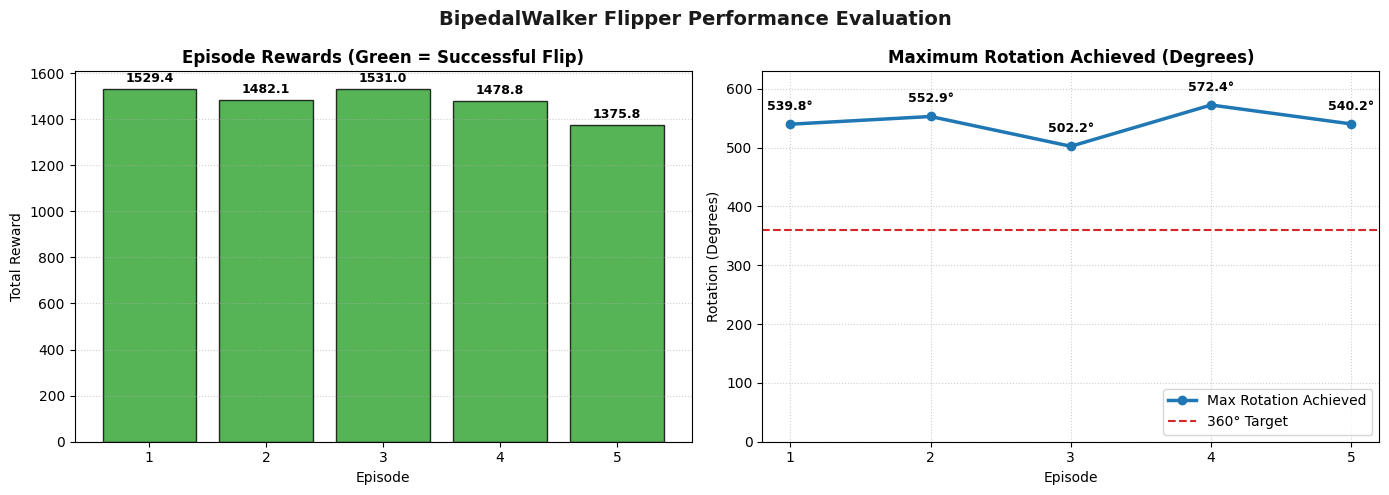

In [2]:
import time
import os
import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# --- ANSI Color Codes for Premium Console Styling ---
class Colors:
    HEADER = '\033[95m'
    BLUE = '\033[94m'
    CYAN = '\033[96m'
    GREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

# 1. Corrected model path to match what was saved at the end of Stage 2
model_path = "ppo_bipedal_final.zip" 
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"{Colors.BOLD}🤖 BIPEDAL WALKER FLIPPER EVALUATION RUN 🤖{Colors.ENDC}")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"• Hardware Device: {Colors.BOLD}{Colors.GREEN}{device.upper()}{Colors.ENDC}")
print(f"• Evaluation Stage: {Colors.BOLD}{Colors.BLUE}Stage 2 (Stabilization and Landing){Colors.ENDC}")

# Create a single human-render environment and wrap it
import custom_bipedal
env = custom_bipedal.BipedalWalker(hardcore=False, render_mode="human")

# 2. Corrected Wrapper name and explicitly set to Stage 2
env = CurriculumFlipperWrapper(env, stage=2)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}. Train and save the model before running tests.")

print(f"• Loading weights from: {Colors.BOLD}{Colors.CYAN}{model_path}{Colors.ENDC}...")
model = PPO.load(model_path, device=device)
print(f"• Model loaded successfully! Starting evaluation...\n")

num_episodes = 5
max_seconds = 5

# Lists to store metrics for final stats and plotting
ep_rewards = []
ep_steps = []
ep_max_angles = []
ep_airtimes = []
ep_successes = []

for ep in range(1, num_episodes + 1):
    obs, info = env.reset()
    start_time = time.time()
    done = False
    total_reward = 0.0
    step_count = 0
    airtime_steps = 0
    
    # Milestone tracking for this episode
    milestones_passed = {90: False, 180: False, 270: False, 360: False}
    max_angle_deg = 0.0

    print(f"{Colors.BOLD}{Colors.BLUE}=================================================={Colors.ENDC}")
    print(f"🤸 {Colors.BOLD}TEST EPISODE {ep} / {num_episodes}{Colors.ENDC}")
    print(f"{Colors.BOLD}{Colors.BLUE}=================================================={Colors.ENDC}")
    print(f"{Colors.BOLD}[Live Event Log]{Colors.ENDC}")
    
    while not done and (time.time() - start_time) < max_seconds:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1
        
        # Track airtime: index 8 and 13 are left and right leg contacts
        if obs[8] == 0.0 and obs[13] == 0.0:
            airtime_steps += 1
            
        # Track maximum rotation reached so far in degrees
        current_angle_rad = info.get("cumulative_angle", 0.0)
        current_angle_deg = abs(current_angle_rad) * (180.0 / np.pi)
        max_angle_deg = max(max_angle_deg, current_angle_deg)
        
        # Check milestones for live logging
        for milestone in [90, 180, 270, 360]:
            if not milestones_passed[milestone] and max_angle_deg >= milestone:
                milestones_passed[milestone] = True
                if milestone == 360:
                    print(f"  ↳ 🌟 {Colors.BOLD}{Colors.GREEN}[360° FULL FLIP COMPLETED!]{Colors.ENDC} at step {step_count}")
                else:
                    print(f"  ↳ 🔄 Milestone {milestone}° passed at step {step_count}")

    # Close of episode metrics
    flip_completed = info.get("flip_completed", False)
    final_angle_rad = info.get("cumulative_angle", 0.0)
    final_angle_deg = final_angle_rad * (180.0 / np.pi)
    
    airtime_pct = (airtime_steps / step_count) * 100 if step_count > 0 else 0.0
    
    # Determine the visual landing/termination outcome
    hull_angle_rad = obs[0]
    is_upright = abs(hull_angle_rad) < 0.4
    
    if flip_completed:
        if is_upright and (obs[8] == 1.0 or obs[13] == 1.0):
            outcome = f"{Colors.BOLD}{Colors.GREEN}🎉 PERFECT LANDING! (Landed upright on feet){Colors.ENDC}"
        elif is_upright:
            outcome = f"{Colors.GREEN}🟢 STABILIZING (Upright in air/landing){Colors.ENDC}"
        else:
            outcome = f"{Colors.WARNING}🟡 FLIPPED but CRASHED / OFF-BALANCE{Colors.ENDC}"
    else:
        if terminated:
            outcome = f"{Colors.FAIL}💥 CRASHED / FELL BEFORE FLIP{Colors.ENDC}"
        else:
            outcome = f"{Colors.CYAN}⏱️ TIMEOUT / INCOMPLETE FLIP{Colors.ENDC}"
            
    # Print beautiful episode summary
    print(f"\n{Colors.BOLD}[Episode Summary]{Colors.ENDC}")
    print(f"  • Outcome:           {outcome}")
    print(f"  • Total Reward:      {Colors.BOLD}{total_reward:.2f}{Colors.ENDC}")
    print(f"  • Total Steps:       {step_count} steps")
    print(f"  • Max Rotation:      {Colors.BOLD}{max_angle_deg:.1f}°{Colors.ENDC} / 360.0° "
          f"({(max_angle_deg/360.0):.1f} flips)")
    print(f"  • Airtime:           {airtime_pct:.1f}% of episode")
    print(f"  • Final Hull Angle:  {final_angle_rad:.2f} rad ({final_angle_deg:.1f}°)")
    print()

    # Append to stat lists
    ep_rewards.append(total_reward)
    ep_steps.append(step_count)
    ep_max_angles.append(max_angle_deg)
    ep_airtimes.append(airtime_pct)
    ep_successes.append(1 if flip_completed else 0)

    time.sleep(0.5)

env.close()

# --- Print Global Evaluation Summary Table ---
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"📊 {Colors.BOLD}GLOBAL EVALUATION METRICS SUMMARY{Colors.ENDC}")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")

success_rate = (sum(ep_successes) / num_episodes) * 100
avg_reward = np.mean(ep_rewards)
std_reward = np.std(ep_rewards)
max_reward_idx = np.argmax(ep_rewards)
avg_steps = np.mean(ep_steps)
avg_max_angle = np.mean(ep_max_angles)
avg_airtime = np.mean(ep_airtimes)

print(f"  • Success Rate (Full Flip): {Colors.BOLD}{Colors.GREEN if success_rate > 50 else Colors.WARNING}{success_rate:.1f}%{Colors.ENDC}")
print(f"  • Average Reward:           {Colors.BOLD}{avg_reward:.2f} ± {std_reward:.2f}{Colors.ENDC}")
print(f"  • Best Reward:              {Colors.BOLD}{Colors.GREEN}{np.max(ep_rewards):.2f}{Colors.ENDC} (Episode {max_reward_idx + 1})")
print(f"  • Average Steps:            {avg_steps:.1f} steps")
print(f"  • Avg Max Rotation:         {avg_max_angle:.1f}°")
print(f"  • Avg Airtime:              {avg_airtime:.1f}%")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}\n")

# --- Generate Premium Jupyter Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BipedalWalker Flipper Performance Evaluation', fontsize=14, fontweight='bold', color='#1a1a1a')

# 1. Plot Rewards
colors_list = ['#2ca02c' if s == 1 else '#d62728' for s in ep_successes]
bars = ax1.bar(range(1, num_episodes + 1), ep_rewards, color=colors_list, edgecolor='black', alpha=0.8)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Episode Rewards (Green = Successful Flip)', fontsize=12, fontweight='semibold')
ax1.set_xlabel('Episode', fontsize=10)
ax1.set_ylabel('Total Reward', fontsize=10)
ax1.set_xticks(range(1, num_episodes + 1))
ax1.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Plot Max Rotation
ax2.plot(range(1, num_episodes + 1), ep_max_angles, marker='o', linewidth=2.5, color='#1f77b4', label='Max Rotation Achieved')
ax2.axhline(360, color='#d62728', linestyle='--', linewidth=1.5, label='360° Target')
ax2.set_title('Maximum Rotation Achieved (Degrees)', fontsize=12, fontweight='semibold')
ax2.set_xlabel('Episode', fontsize=10)
ax2.set_ylabel('Rotation (Degrees)', fontsize=10)
ax2.set_xticks(range(1, num_episodes + 1))
ax2.set_ylim(0, max(400, max(ep_max_angles) * 1.1))
ax2.grid(linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')

for idx, val in enumerate(ep_max_angles):
    ax2.annotate(f'{val:.1f}°',
                xy=(idx + 1, val),
                xytext=(0, 8),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()